# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

P.S. Do NOT use odd system sizes, everything breaks because of the way that the polarized boundary conditions work.

# ED Implementation using QuSpin

## Reset Simulation

In [10]:
import gc
import os
import shutil

shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states")
shutil.rmtree(f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")

# fetch the file you are studying

gc.collect()


6993

## Exact Diagonalization

In [11]:
from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ed_utils import *


# try breaking different symmetries
L        = 18
J        = 1

start    = 0
end      = 2
step     = 0.1

scan_var = "h"
values   = np.arange(start, end+step, step)
# values   = [10**i for i in np.arange(0, 2.1, 0.1)]
# values = values[:4]
opp      = "k" if scan_var == "h" else "h"
set      = 0

# perform ed
basis = spin_basis_1d(L, pauli=1)

def exact_diagonalization_line(values, scan_var, opp, set, basis, L, J=1, bc="obc"):
    '''Perform exact diagonalization across a line on the parameter space of your phase diagram'''
    if not os.path.exists("ed_results"):
        os.mkdir("ed_results")

    folder_eigenstates = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
    folder_eigenvalues = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values"

    if not os.path.exists(folder_eigenstates):
        os.mkdir(folder_eigenstates)
        os.mkdir(folder_eigenvalues)
    else:
        return 1
    
    for ind, val in tqdm(enumerate(values)):
        # determine h and k
        if scan_var == "h":
            h = val
            k_r = set
            k_l = set
        else:
            h = set     
            k_r = val
            k_l = val

        print("running for (J,h, kl, kr)=", J, h, k_l, k_r)
        # --- Hamiltonian ---
        if bc == "obc":
            # open boundary conditions

            J_term = [[J, i, i+1] for i in range(L-1)]   
            h_term = [[h, i] for i in range(L)]  

            xy_term = [[k_r, i, i+2] for i in range(L-2)]
            yx_term = [[-k_l, i, i+2] for i in range(L-2)]
            xyz_term = [[k_l, i, i+1,i+2] for i in range(L-2)]
            zyx_term = [[-k_r, i, i+1, i+2] for i in range(L-2)]
        else:
            # periodic boundary conditions

            J_term = [[J, i, (i+1)% L] for i in range(L)]   
            h_term = [[-h, i] for i in range(L)]  

            xy_term = [[k_r, i, (i+2) % L] for i in range(L)]
            zyx_term = [[-k_r, i, (i+1)% L, (i+2)% L] for i in range(L)]

            yx_term = [[-k_l, i, (i+2)% L] for i in range(L)]
            xyz_term = [[k_l, i, (i+1)% L,(i+2)% L] for i in range(L)]

        static = [
            ["xx", J_term]
            , ["z",  h_term]
            , ["xy", xy_term]
            , ["yx", yx_term]
            , ["xyz", xyz_term]
            , ["zyx", zyx_term]
        ]

        # add static fields
        g = 1e-3
        # static.append(["x", [[(-1)**i * g, i] for i in range(L)]])  # break J parity symmetry
        # static.append(["y", [[(-1)**i * g, i] for i in range(L)]])
        # static.append(["z", [[(-1)**i * g, i] for i in range(L)]]) # break k parity symmetry

        H = hamiltonian(static, [], basis=basis, dtype=np.complex128, check_symm=False, check_herm=False)
        E, psi = H.eigsh(k=10, which="SA")  # look at low lying states only
        np.savetxt(os.path.join(os.getcwd(), folder_eigenvalues, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_energies"), E)

        n = 1
        for i in range(n):
            psi_temp = psi[:,i]
            # write it in a .txt file for easy access
            np.save(os.path.join(os.getcwd(), folder_eigenstates, f"{opp}{scan_var}_{set:.10f}_{val:.10f}_state_{i}"), psi_temp)

exact_diagonalization_line(values=values, scan_var=scan_var, opp=opp, set=set, basis=basis, L=L, J=J, bc="obc")




0it [00:00, ?it/s]

running for (J,h, kl, kr)= 1 0.0 0 0


1it [00:28, 28.27s/it]

running for (J,h, kl, kr)= 1 0.1 0 0


2it [01:44, 56.33s/it]

...

19it [10:25, 32.90s/it]

running for (J,h, kl, kr)= 1 1.9000000000000001 0 0


20it [10:58, 32.78s/it]

running for (J,h, kl, kr)= 1 2.0 0 0


21it [11:31, 32.92s/it]


## Energy Profile

/home/silvanita/Desktop/thesis/master_thesis/books/ed_results/L14_h0_k0-20_values
hk_0.0000000000_0.0000000000_energies


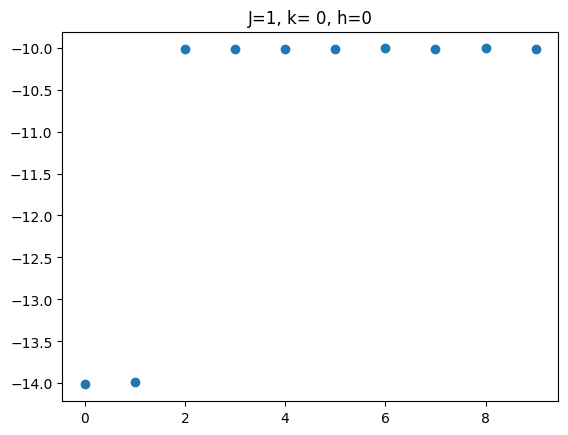

hk_0.0000000000_1.0000000000_energies


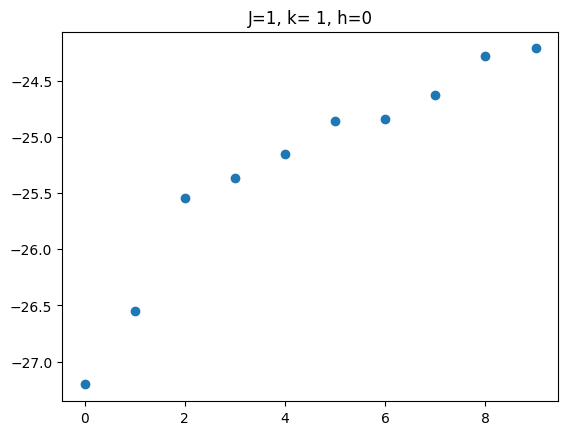

hk_0.0000000000_2.0000000000_energies


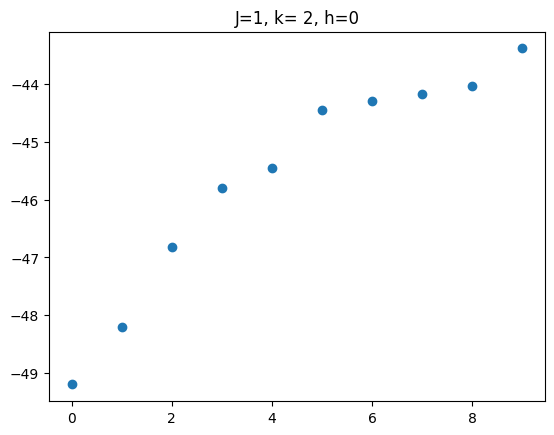

hk_0.0000000000_3.0000000000_energies


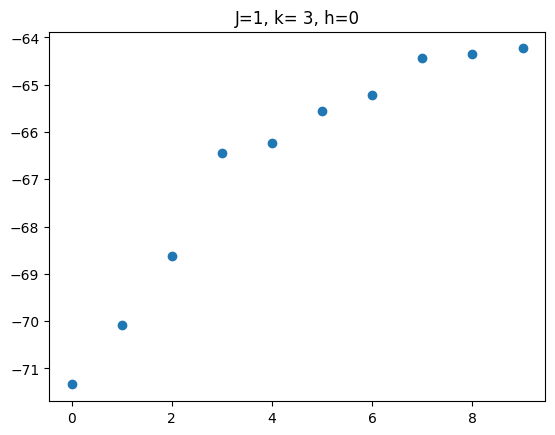

hk_0.0000000000_4.0000000000_energies


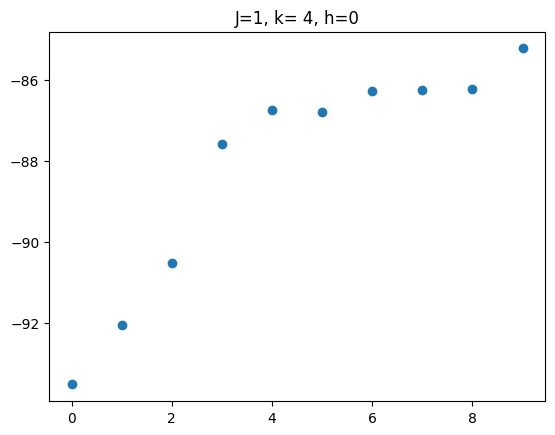

hk_0.0000000000_5.0000000000_energies


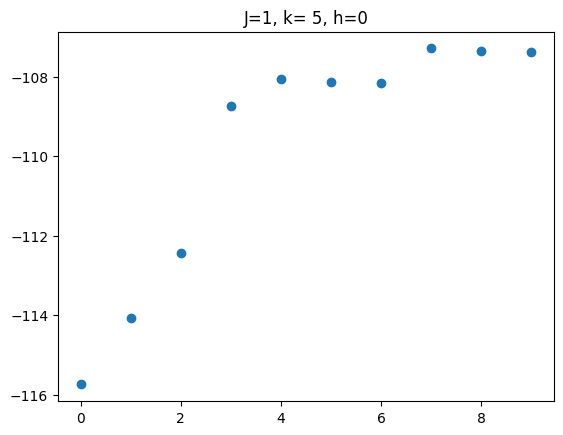

hk_0.0000000000_6.0000000000_energies


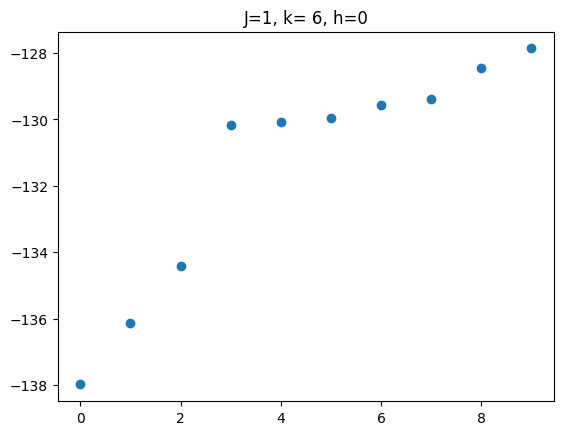

hk_0.0000000000_7.0000000000_energies


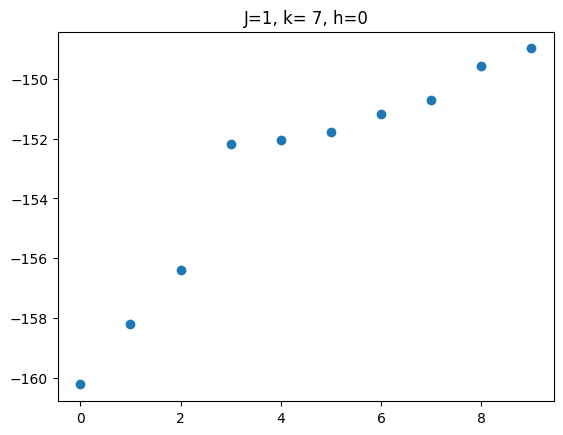

hk_0.0000000000_8.0000000000_energies


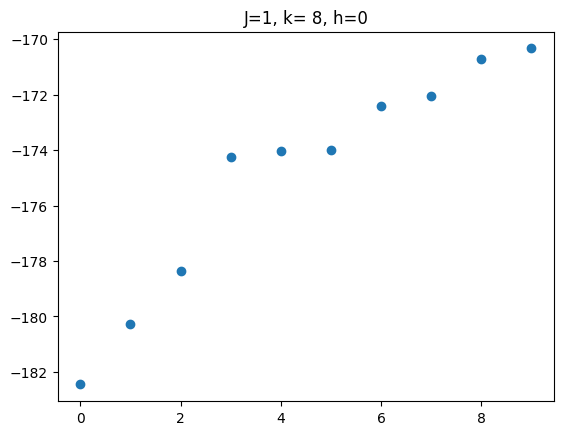

hk_0.0000000000_9.0000000000_energies


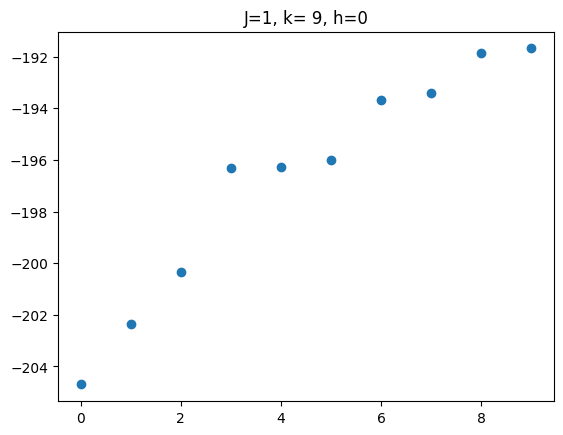

hk_0.0000000000_10.0000000000_energies


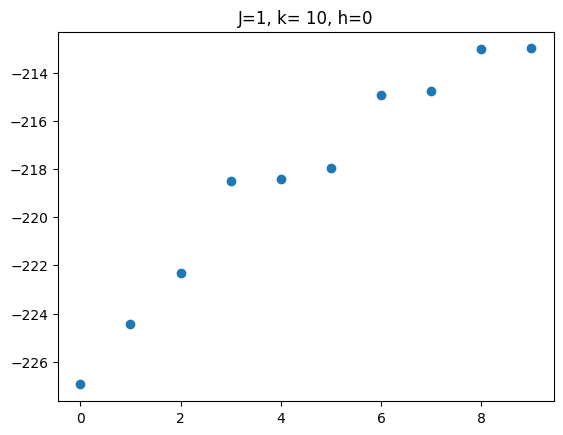

hk_0.0000000000_11.0000000000_energies


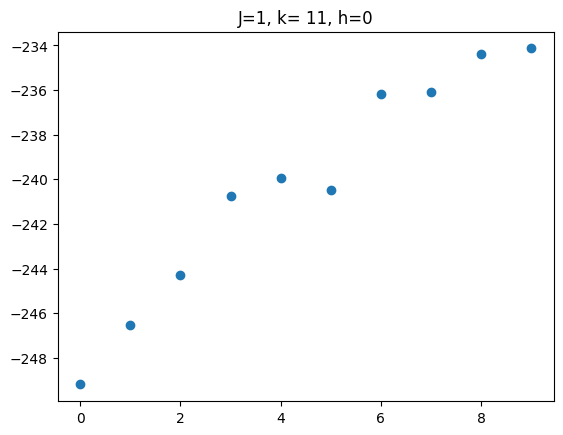

hk_0.0000000000_12.0000000000_energies


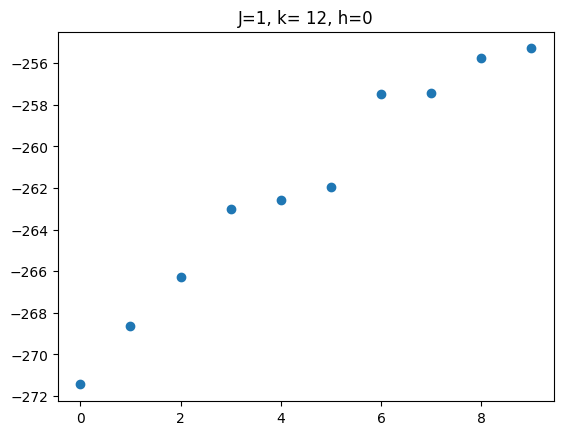

hk_0.0000000000_13.0000000000_energies


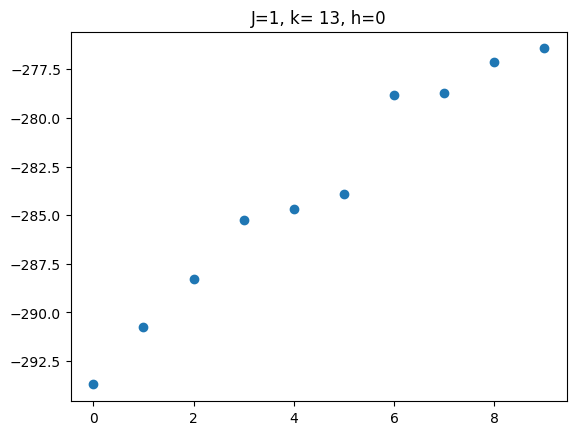

hk_0.0000000000_14.0000000000_energies


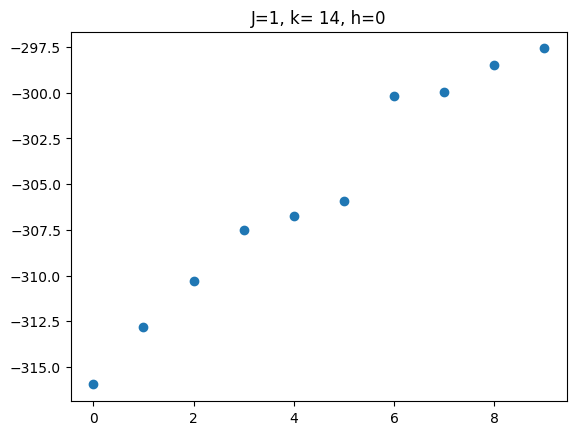

hk_0.0000000000_15.0000000000_energies


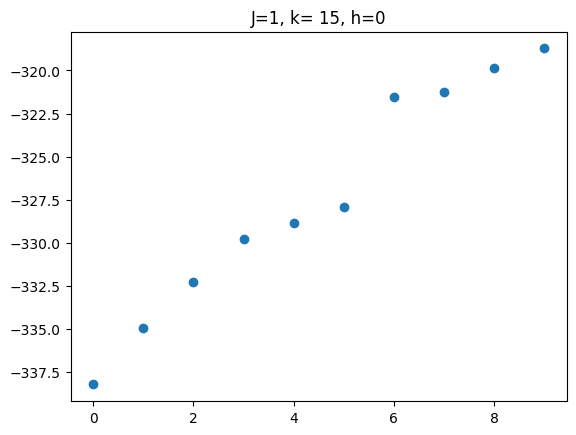

hk_0.0000000000_16.0000000000_energies


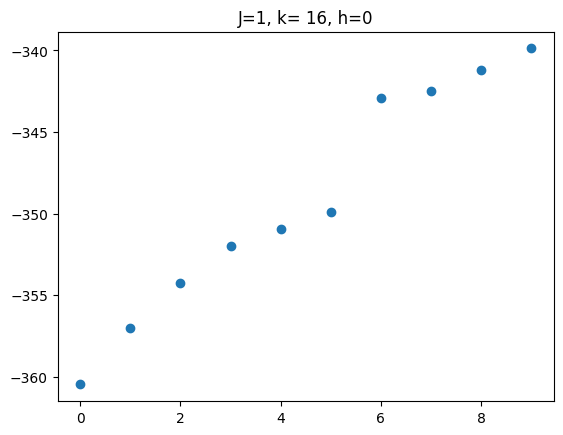

hk_0.0000000000_17.0000000000_energies


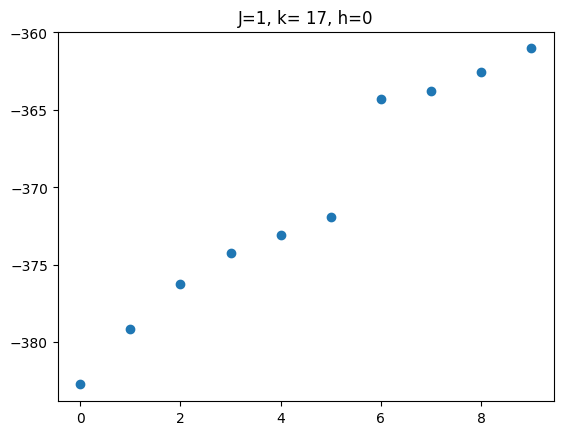

hk_0.0000000000_18.0000000000_energies


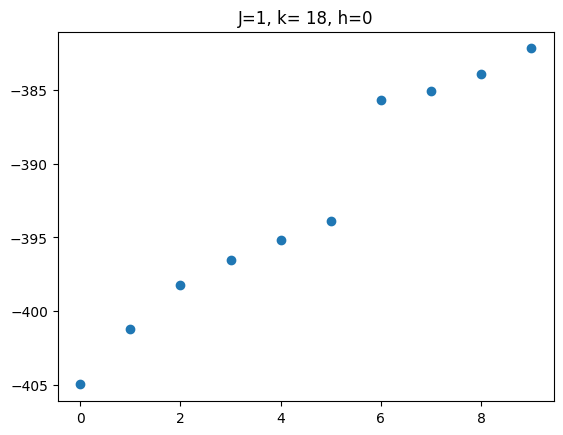

hk_0.0000000000_19.0000000000_energies


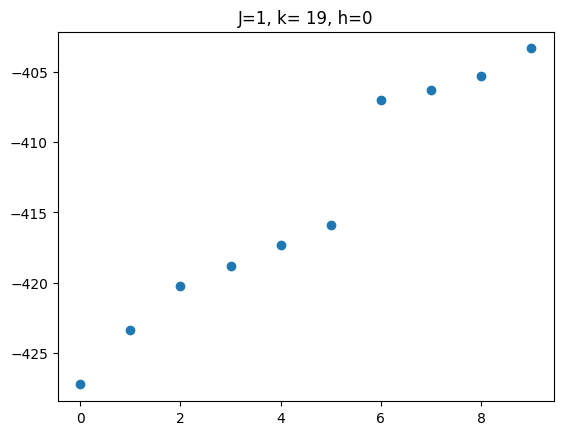

hk_0.0000000000_20.0000000000_energies


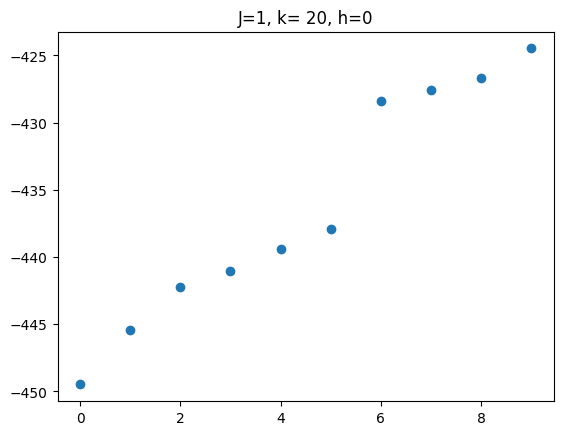

In [178]:
# plot energy spectrum
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
loc = os.path.join(os.getcwd(), f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_values")
print(loc)

gs_energy = []
for (i, v) in zip(sorted(os.listdir(loc), key=lambda x: float(x.split('_')[2])), values):
    print(i)
    energy = np.loadtxt(os.path.join(loc, i))
    # energy = sorted(energy)
    plt.scatter(range(len(energy)), energy)
    gs_energy.append(energy[0])
    plt.title(f"J={J}, {scan_var}= {v}, {opp}={set}")
    plt.show()


## Magnetization Profile

41it [00:07,  5.14it/s]


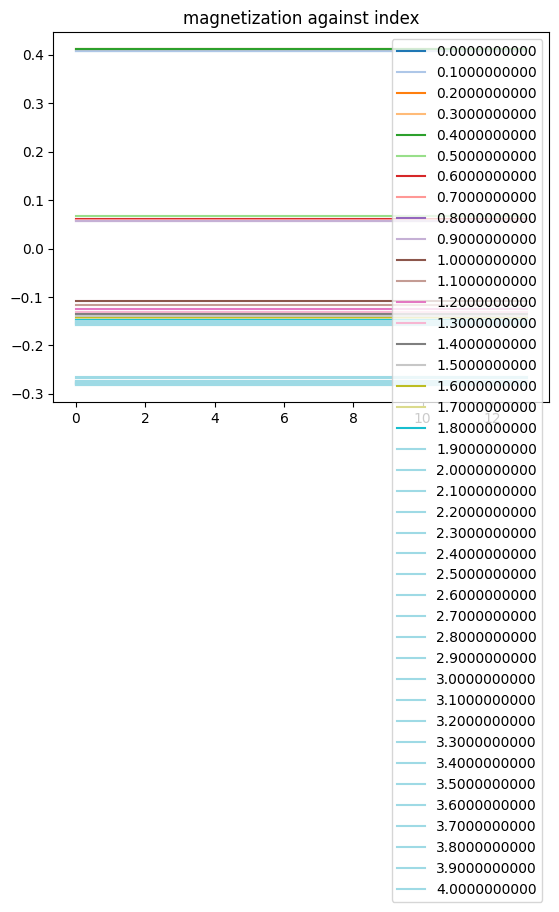

In [ ]:
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
var_num = len(values)
colors = plt.cm.Greens(np.linspace(0.3, 1, 4))

def magnetization_string(op, psi, basis, dist=2, part="real"):
    '''Magnetization across entire string'''
    op_string = []
    L = basis.N
    ops = list(op)
    
    for i in range(L):

        local_operator = []
        for ind, o in enumerate(ops):
            local_operator.append((o, [[1.0, (i + ind*dist) % L]]))
        operator = quantum_LinearOperator(local_operator, basis=basis, check_symm=False, check_herm=False,dtype=np.complex128)
        mx = operator.expt_value(psi)
        mx = np.real(mx) if part=="real" else np.imag(mx)
        op_string.append(mx)
    return np.array(op_string)

cmap = plt.get_cmap("tab20")
foo = 0
indices_mx, final_mx, final_mx2 = [], [], []
for ind, i in tqdm(enumerate(sorted(os.listdir(results), key= lambda x: float(x.split("_")[2])))):
    psi = np.load(os.path.join(results,i))
    index = i.split("_")
    # --- string measurements ---
    mx_list = magnetization_string("z", psi, basis,dist=1)
    # my_list = magnetization_string("z", psi, basis, dist=0)
    my_list = magnetization_string("y", psi, basis,dist=0)
    mz_list = magnetization_string("z", psi, basis,dist=0)

    if index[-1] == "0.npy":

        # print(i)
        plt.plot(mx_list, color=cmap(foo), label=f"{index[2]}")
        # plt.plot(my_list, color=cmap(foo), label=f"{index[2]}")
        # plt.plot(mz_list, color=cmap(foo), label=f"{index[2]}")

        # indices_mx.append(np.log10(float(index[2])))
        # final_mx.append(np.abs((0+1j) * mx_list[L//2]))
        # final_mx2.append(my_list[L//2])
        # plt.plot(mx_list2, color=cmap(foo), label=f"y, {i}")
        # plt.plot(mx_list3, color=cmap(foo), label=f"z, {i}")
        # print(mx_list3)
        # plt.ylim(-1,1)
        plt.legend()
        foo += 1

        plt.title(f"magnetization against index")
        plt.legend()
        # plt.show()

# plt.plot(indices_mx, final_mx, label="xiy")
# plt.plot(indices_mx, final_mx2, label="z")
plt.legend()

## Entanglement

41it [00:05,  7.30it/s]


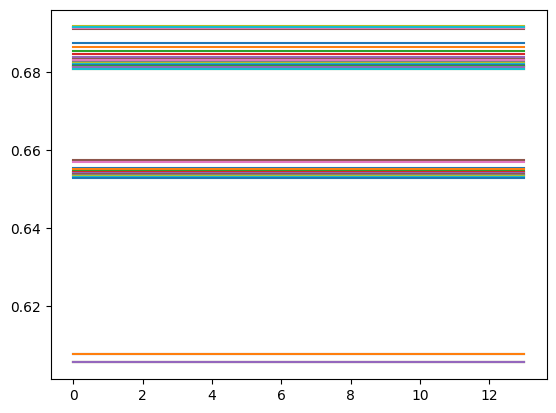

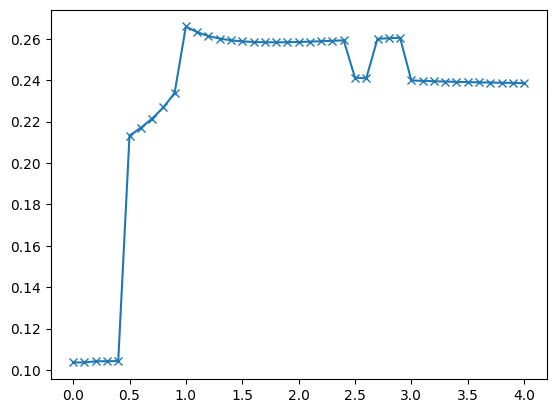

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4. ]


In [200]:
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"
var_num = len(values)
def entanglement_site(psi, basis):
    L = int(np.log2(len(psi)))
    mid = list(range(L//2))
    ent_mid = basis.ent_entropy(psi, sub_sys_A=mid)["Sent_A"]
    return ent_mid

def entanglement_string(psi, basis):
    s_sites = []
    L = int(np.log2(len(psi)))

    for i in range(L):
        ent = basis.ent_entropy(psi, sub_sys_A=[i])
        s_sites.append(ent["Sent_A"])

    return s_sites

# --- entropy ---
single_site_entropy_curves = []
half_chain_entropy = []


for ind, i in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results,i))
    
    #--- Entanglement---
    single_site_entropy_curves.append(entanglement_site(psi, basis))
    half_chain_entropy = entanglement_string(psi, basis)
    plt.plot(half_chain_entropy, label=f"{i}")
# plt.legend()
plt.show()

plt.plot(values, single_site_entropy_curves, marker="x")
plt.show()
print(values)


## Correlator

11it [00:03,  2.81it/s]


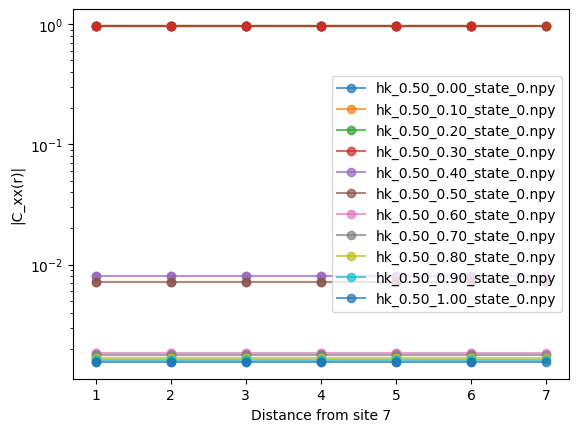

In [ ]:
def correlator(op1, op2, i, j, psi, basis):
    '''Connected correlator: g(op1, op2) = <op1_i op2_j> - <op1_i><op2_j>'''
    # Create the two-point operator op1_i * op2_j
    operators = [[op1, [[1.0, i]]], [op2, [[1.0, j]]]]
    corr_op = quantum_LinearOperator(operators, basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    
    # Expectation value <op1_i op2_j>
    corr = np.real(psi.conj() @ corr_op.dot(psi))
    
    # Single-point expectations
    op_i = quantum_LinearOperator([[op1, [[1.0, i]]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_i = np.real(psi.conj() @ op_i.dot(psi))
    
    op_j = quantum_LinearOperator([[op2, [[1.0, j]]]], basis=basis, check_symm=False, check_herm=False, dtype=np.complex128)
    exp_j = np.real(psi.conj() @ op_j.dot(psi))
    
    connected_correlator = corr - (exp_i * exp_j)
    return connected_correlator

def correlator_string(op1, op2, psi, basis, reference_site=None, bc="pbc"):
    '''Calculate correlations from one reference site to all other sites'''
    L = basis.N
    
    # Use middle site as default reference to minimize boundary effects
    if reference_site is None:
        reference_site = L // 2
    
    distances = []
    correlations = []
    
    for j in range(L):
        if j == reference_site:
            continue  # Skip self-correlation
            
        if bc == "pbc":
            # For PBC, use minimum image convention
            dist = min(abs(j - reference_site), L - abs(j - reference_site))
        else:
            dist = abs(j - reference_site)
            
        corr_val = correlator(op1, op2, reference_site, j, psi, basis)
        
        distances.append(dist)
        correlations.append(corr_val)
    
    return distances, correlations

# Usage - pick one consistent reference site
reference_site = L // 2  # Middle of the chain

for ind, filename in tqdm(enumerate(sorted(os.listdir(results)))):
    psi = np.load(os.path.join(results, filename))
    
    # Calculate correlations from the same reference site for all states
    distance, corr = correlator_string("x", "y", psi, basis, reference_site=reference_site, bc="pbc")
    
    plt.semilogy(distance, np.abs(corr), 'o-', label=filename, alpha=0.7)

plt.xlabel(f'Distance from site {reference_site}')
plt.ylabel('|C_xx(r)|')
plt.legend()
plt.show()

In [164]:
def system_health_check(psi, basis, H=None):
    """Run basic diagnostics on your system"""
    L = basis.N
    
    print("=== SYSTEM HEALTH CHECK ===")
    print(f"System size: {L}")
    print(f"State dimension: {len(psi)}")
    print(f"State norm: {np.linalg.norm(psi):.10f}")
    
    # Check if state is normalized
    if abs(np.linalg.norm(psi) - 1.0) > 1e-10:
        print("⚠️  State is not normalized!")
        psi = psi / np.linalg.norm(psi)
    
    # Check energy expectation if Hamiltonian is provided
    if H is not None:
        energy = np.real(psi.conj() @ H.dot(psi))
        print(f"Energy expectation: {energy:.6f}")
    
    return psi

# Check single-site expectations to see magnetization patterns
def check_magnetizations(psi, basis):
    """Check if there's any spontaneous symmetry breaking"""
    L = basis.N
    mag_x, mag_y, mag_z = [], [], []
    
    for i in range(L):
        # X magnetization
        op_x = quantum_LinearOperator([["x", [[1.0, i]]]], basis=basis, dtype=np.complex128)
        mag_x.append(np.real(psi.conj() @ op_x.dot(psi)))
        
        # Y magnetization  
        op_y = quantum_LinearOperator([["y", [[1.0, i]]]], basis=basis, dtype=np.complex128)
        mag_y.append(np.real(psi.conj() @ op_y.dot(psi)))
        
        # Z magnetization
        op_z = quantum_LinearOperator([["z", [[1.0, i]]]], basis=basis, dtype=np.complex128)
        mag_z.append(np.real(psi.conj() @ op_x.dot(psi)))
    
    plt.figure(figsize=(12, 3))
    plt.subplot(131)
    plt.plot(mag_x, 'o-')
    plt.title('X magnetization')
    plt.subplot(132)
    plt.plot(mag_y, 'o-')
    plt.title('Y magnetization')
    plt.subplot(133)
    plt.plot(mag_z, 'o-')
    plt.title('Z magnetization')
    plt.tight_layout()
    plt.show()
    
    return mag_x, mag_y, mag_z

## Central Charge

0it [00:00, ?it/s]

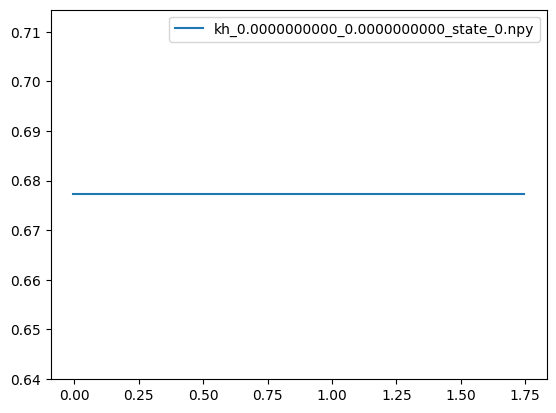

1it [00:00,  1.83it/s]

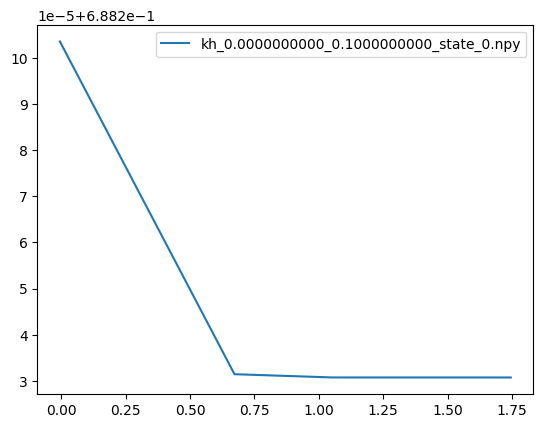

2it [00:01,  1.85it/s]

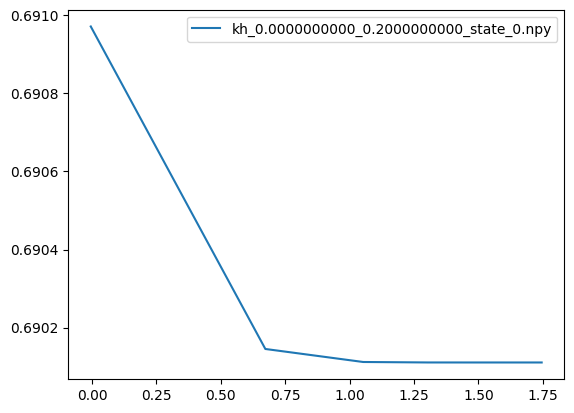

3it [00:01,  1.94it/s]

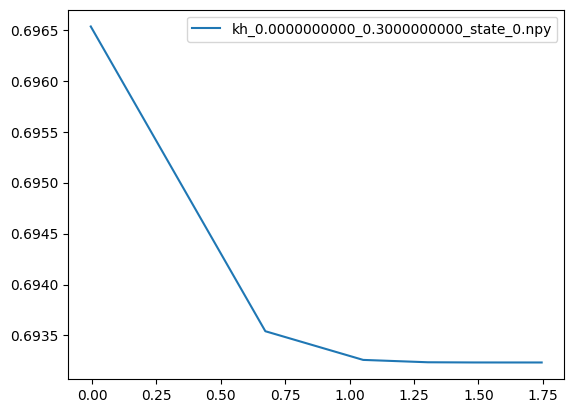

4it [00:02,  1.93it/s]

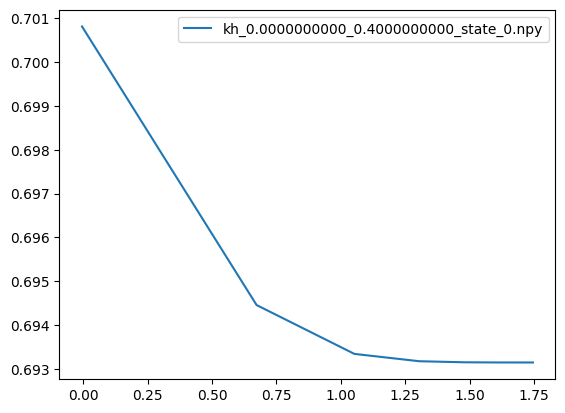

5it [00:02,  1.95it/s]

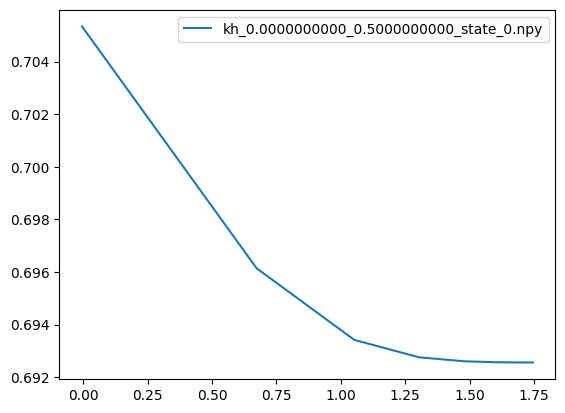

6it [00:03,  1.94it/s]

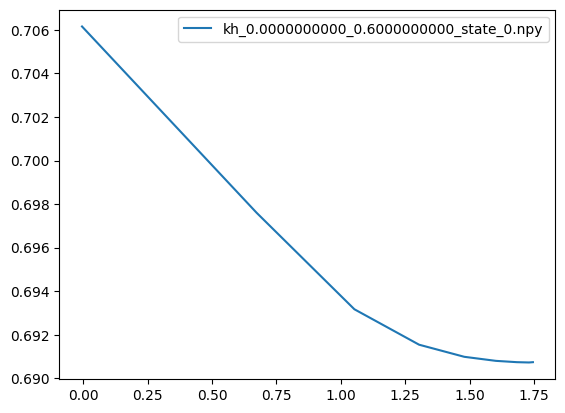

7it [00:03,  1.97it/s]

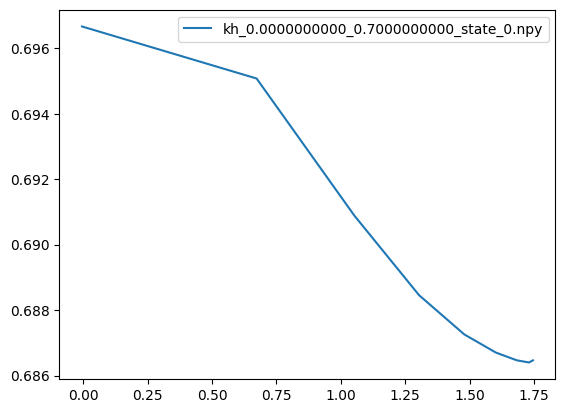

8it [00:04,  1.92it/s]

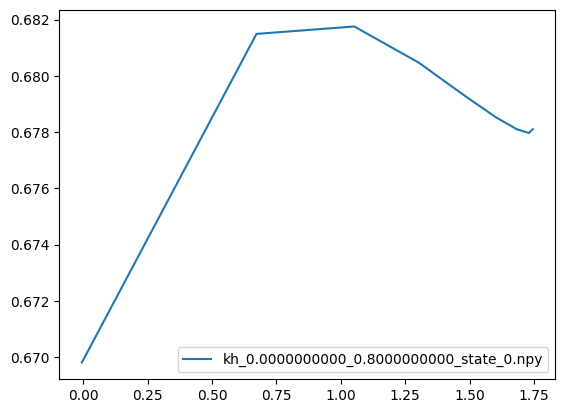

9it [00:04,  1.96it/s]

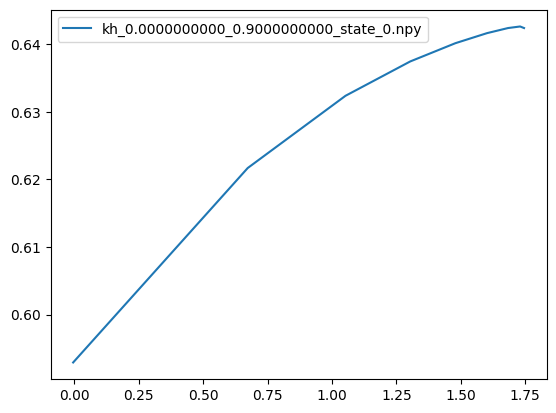

10it [00:05,  1.95it/s]

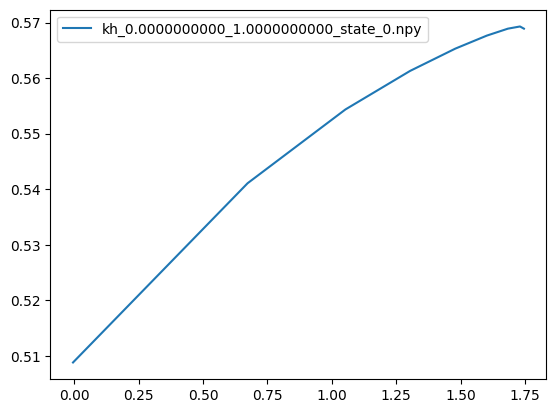

11it [00:05,  1.95it/s]

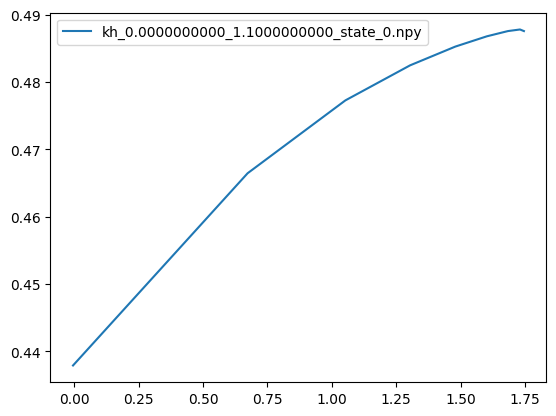

12it [00:06,  1.93it/s]

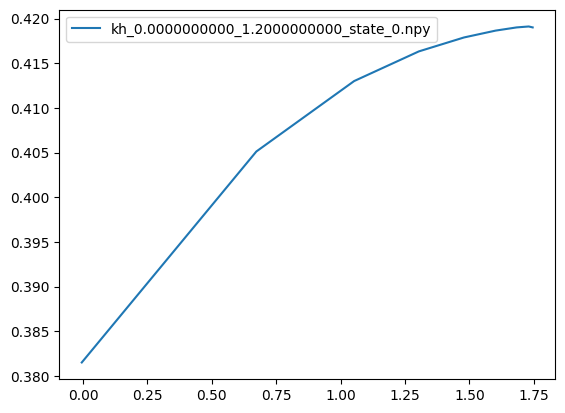

13it [00:06,  1.93it/s]

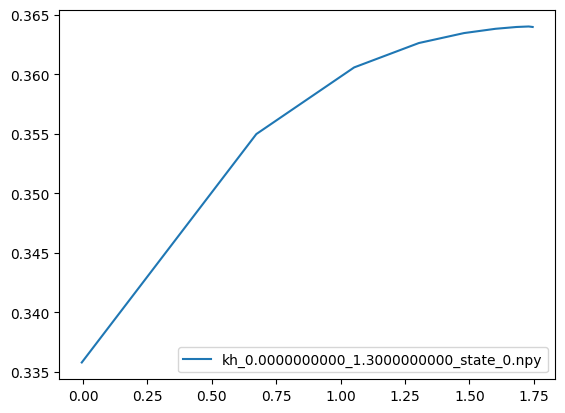

14it [00:07,  1.93it/s]

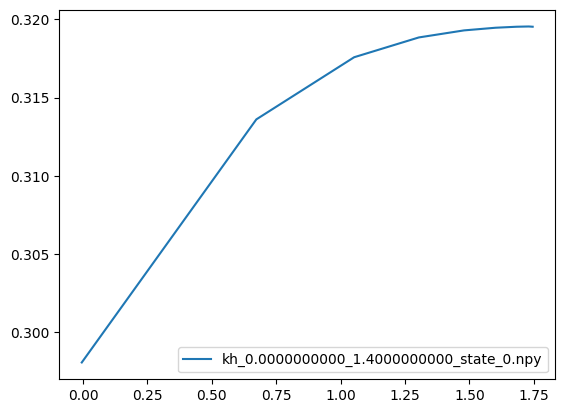

15it [00:07,  1.98it/s]

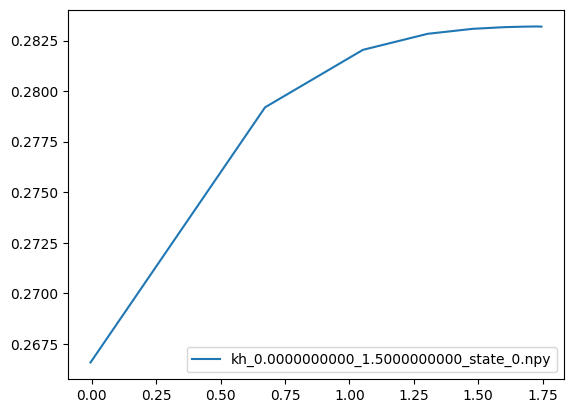

16it [00:08,  1.89it/s]

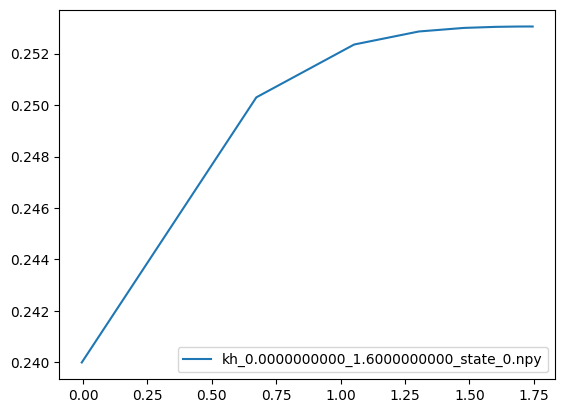

17it [00:08,  1.77it/s]

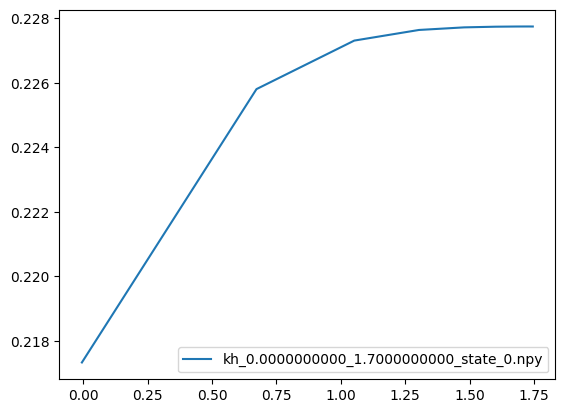

18it [00:09,  1.82it/s]

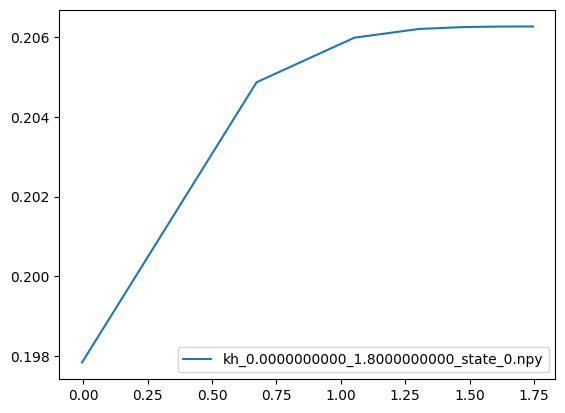

19it [00:09,  1.94it/s]

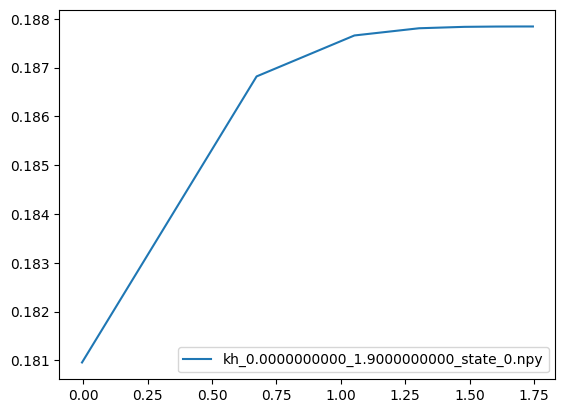

20it [00:10,  1.96it/s]

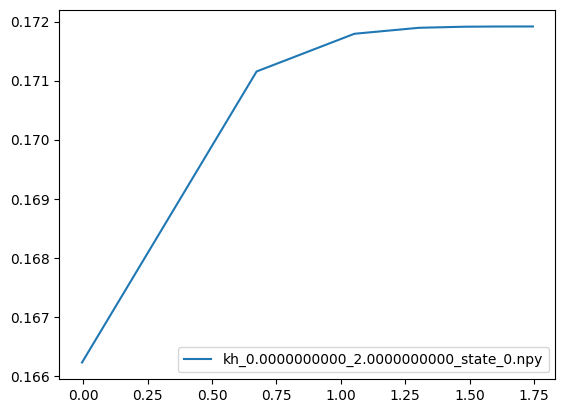

21it [00:10,  1.93it/s]


In [16]:
# Calculate central charge
results = f"ed_results/L{L}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}_states"

def bond_entanglement_entropy(psi, basis, site_i, site_j):
    """
    Calculate entanglement entropy between two sites i and j.
    
    Parameters:
    psi: ground state wavefunction
    basis: QuSpin basis object
    site_i, site_j: indices of the two sites (should be neighbors for S(i,i+1))
    
    Returns:
    S: von Neumann entanglement entropy between sites i and j
    """
    # Create list of sites for the reduced density matrix
    sites = [site_i, site_j]
    
    # Get reduced density matrix for these two sites
    rho_ij = basis.partial_trace(psi, sites)
    
    # Calculate eigenvalues and entanglement entropy
    eigvals = np.linalg.eigvalsh(rho_ij)
    
    # Remove zero eigenvalues (numerical stability)
    eigvals = eigvals[eigvals > 1e-15]
    
    # Von Neumann entropy: S = -∑ λ ln λ
    S = -np.sum(eigvals * np.log(eigvals))
    
    return S

def all_bond_entropies(psi, basis, L):
    """
    Calculate S(i,i+1) for all bonds in the chain.
    
    Returns:
    positions: bond positions (center between sites)
    entropies: S(i,i+1) values
    """
    positions = []
    entropies = []
    
    for i in range(1,L//2+1):  # For open boundaries
        S = bond_entanglement_entropy(psi, basis, i, i+1)
        positions.append(i)  # Bond center
        entropies.append(S)
    
    return np.array(positions), np.array(entropies)

def s_calabrese_cardy(x, c, s0):
    return (c/6) * x + s0

for ind, i in tqdm(enumerate(sorted(os.listdir(results), key= lambda x: float(x.split("_")[2])))):
    psi = np.load(os.path.join(results,i))
    positions, S = all_bond_entropies(psi, basis, L)

    x0 = np.log((L/np.pi) * np.sin(np.pi * positions / L))  # linearize

    plt.plot(x0, S, label=f"{i}")
    plt.legend()
    plt.show()

# Compare DMRG w/ ED

IndexError: list index out of range

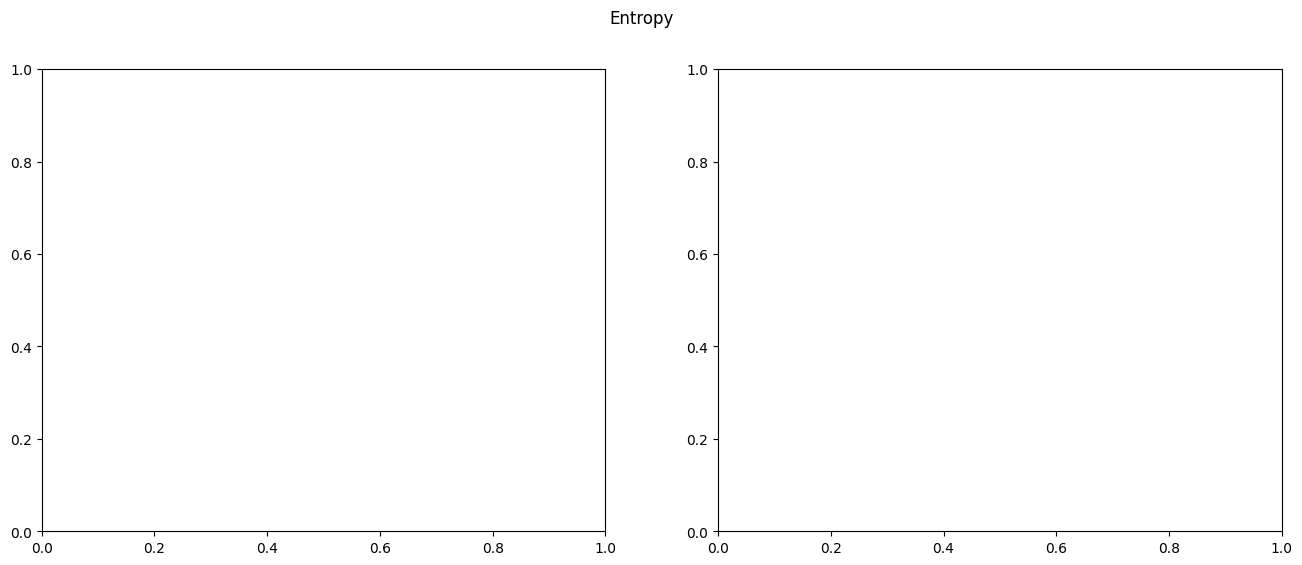

In [32]:
# --- entropy ---
filename= os.path.join(os.getcwd(), f"dmrg_results/run_L{L+4}_{opp}{set}_{scan_var}{np.min(values)}-{np.max(values)}")

def plot_entropy(dmrg_path, single_site, half_chain, scan_var, values, opp, set):
    fig, ax = plt.subplots(1, 2, figsize=(16,6))
    fig.suptitle("Entropy")

    s_mid = []

    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0.3, 0.85, len(values)))

    for i, (v, c) in enumerate(zip(values, colors)):
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/S.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/S.txt")
        try:
            ind, _, s = np.loadtxt(loc, dtype=np.complex128).T
            ind = [i - 2 for i in ind]
            mid_site = len(s) // 2
            s_mid.append(s[mid_site])
            ax[0].plot(ind, s, ls="--", color=c)  # DMRG
        except Exception:
            # No DMRG data → skip plotting
            pass

        ax[0].plot(single_site[i], color=c, label=f"ED, {scan_var}={v:.2f}")

    ax[0].set_title(f"Single-site entanglement entropy for {opp}={set}")
    ax[0].legend()

    # --- half-chain entropy compare ---
    ax[1].plot(values, half_chain, "-o", label="ED")
    if len(s_mid) == len(values):
        ax[1].plot(values, s_mid, "x-", color="red", label="DMRG")

    ax[1].set_title(f"Half-chain entanglement vs {scan_var}")
    ax[1].set_xlabel(f"{scan_var}")
    ax[1].set_ylabel("S_half")
    ax[1].legend()

    plt.grid()
    plt.show()


plot_entropy(filename, single_site_entropy_curves, half_chain_entropy, values=values, scan_var=scan_var, opp=opp, set=set)

In [ ]:
# --- string magnetization ----
def plot_string(dmrg_path, op, values, string_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    colors = cmap(np.linspace(0, 0.5, len(values)))
    plt.figure(figsize=(6, 6))
    for ind, (v, c) in enumerate(zip(values, colors)):
        

        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        # --- Try loading DMRG file ---
        try:
            index_dmrg, site_measurements_dmrg = np.loadtxt(loc).T
            has_dmrg = True
        except Exception:
            has_dmrg = False

        # --- ED ---
        plt.plot(
            range(len(string_measurements_ed.T)),
            string_measurements_ed[ind],
            label=f"{v}",
            color=c
        )

        # --- DMRG (optional) ---
        if has_dmrg:
            plt.scatter(
                [i-2 for i in index_dmrg],
                site_measurements_dmrg,
                marker="x",
                color=c,
            )

    plt.title(f"Magnetization {op} (string) for {opp}={set}")
    plt.xlabel("Site index")
    plt.ylabel(f"{op}")
    plt.ylim(-1, 1)
    plt.legend()
    plt.grid()
    plt.show()


plot_string(filename, 'X', values, mx_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Y', values, my_list, scan_var=scan_var, opp=opp, set=set)
plot_string(filename, 'Z', values, mz_list, scan_var=scan_var, opp=opp, set=set)

IndexError: list index out of range

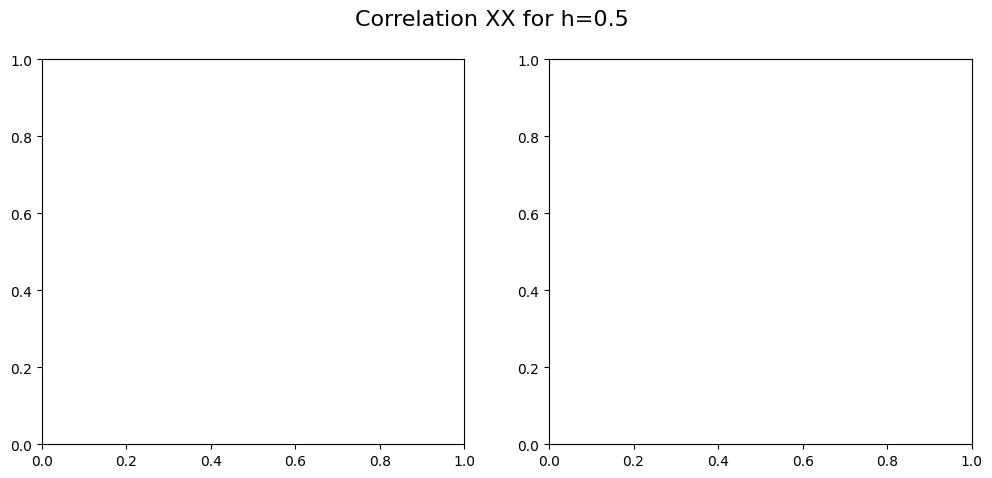

In [ ]:
def plot_correlator_simple(dmrg_path, op, values, ed_distances, ed_correlations, scan_var, opp, set_val, orientation="semilogy"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Correlation {op} for {opp}={set_val}", fontsize=16)

    # Colormaps
    cmap_ed = plt.cm.viridis
    cmap_dmrg = plt.cm.inferno
    colors_ed = cmap_ed(np.linspace(0, 1, len(values)))
    colors_dmrg = cmap_dmrg(np.linspace(0, 1, len(values)))

    L = len(ed_correlations[0]) + 1  # +1 because we skipped self-correlation
    
    for ind, (v, c_ed, c_dmrg) in enumerate(zip(values, colors_ed, colors_dmrg)):
        # ---------------- ED DATA ----------------
        x_ed = [L - i  for i in ed_distances[ind]]
        y_ed = ed_correlations[ind]  # Use real part to see signs
        label_ed = f"{scan_var}={v:.2f}"

        # ---------------- DMRG DATA ----------------
        if scan_var == "h":
            loc = os.path.join(dmrg_path, f"{v:.2f}_{set_val:.2f}_{set_val:.2f}/OUT/out_{v:.3f}_{set_val:.3f}_{set_val:.3f}/{op}.txt")
        else:
            loc = os.path.join(dmrg_path, f"{set_val:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set_val:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

        x_dmrg, y_dmrg = [], []

        if os.path.exists(loc):
            try:
                r = np.loadtxt(loc, dtype=np.complex128)
                if r.ndim == 1:
                    r = r.reshape(1, -1)
                for row in r:
                    i, j, corr = row
                    if int(i) == (L+4)//2:
                        print(i, j)
                        distance = np.abs(int(j) - int(i))
                        x_dmrg.append(distance)
                        y_dmrg.append(corr)
            except Exception as e:
                pass

        # ---------------- PLOTTING ----------------
        if orientation == "semilogy":
            ax[0].semilogy(x_ed, np.abs(y_ed), "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].semilogy(x_dmrg, np.abs(y_dmrg), "-x", color=c_ed, label=label_ed)
        elif orientation == "loglog":
            ax[0].loglog(x_ed, np.abs(y_ed), "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].loglog(x_dmrg, np.abs(y_dmrg), "-x", color=c_ed, label=label_ed)
        else:
            ax[0].plot(x_ed, y_ed, "-o", color=c_ed, label=label_ed)
            if x_dmrg:
                ax[1].plot(x_dmrg, y_dmrg, "-x", color=c_ed, label=label_ed)

    # ---------------- AXIS SETUP ----------------
    ax[0].set_xlabel("Distance from site 2")
    ax[0].set_ylabel(f"⟨{op}⟩")
    ax[0].grid(True)
    # ax[0].legend()

    ax[1].set_xlabel("Distance from middle site")
    ax[1].set_ylabel(f"⟨{op}⟩")
    ax[1].grid(True)
    # ax[1].legend()

    plt.tight_layout()
    plt.show()


# GRAVEYARD

In [ ]:
# def plot_string(dmrg_path, op, values, string_measurements_ed, scan_var, opp, set, counter=False, colors="black"):
#     # cmap = plt.cm.inferno
#     # colors = cmap(np.linspace(0, 0.5, len(values)))

#     for ind, (v, c) in enumerate(zip(values, colors)):
#         if scan_var == "h":
#             loc = os.path.join(dmrg_path, f"{v:.2f}_{set:.2f}_{set:.2f}/OUT/out_{v:.3f}_{set:.3f}_{set:.3f}/{op}.txt")
#         else:
#             loc = os.path.join(dmrg_path, f"{set:.2f}_{v:.2f}_{v:.2f}/OUT/out_{set:.3f}_{v:.3f}_{v:.3f}/{op}.txt")

#         # --- Try loading DMRG file ---
#         try:
#             index_dmrg, site_measurements_dmrg = np.loadtxt(loc).T
#             has_dmrg = True
#         except Exception:
#             has_dmrg = False
#         label = f"{v}, {counters}" if counter else f"{v}"
#         color = colors[counter%4] if counter else "black"
#         # --- ED ---
#         plt.plot(
#             string_measurements_ed,
#             label=label,
#             color=color
#         )

#         # --- DMRG (optional) ---
#         if has_dmrg:
#             plt.scatter(
#                 [i-2 for i in index_dmrg],
#                 site_measurements_dmrg,
#                 marker="x"
#                 # color=c,
#             )

#     plt.title(f"Magnetization {op} (string) for {opp}={set}")
#     plt.xlabel("Site index")
#     plt.ylabel(f"{op}")
#     plt.ylim(-1, 1)
#     plt.legend()
#     plt.grid()

In [ ]:
# --- site magnetization ---
def plot_site(dmrg_path, op, values, site_measurements_ed, scan_var, opp, set):
    cmap = plt.cm.inferno
    cmap2 = plt.cm.viridis
    color = cmap(0.6)
    color2 = cmap2(0.6)

    site_measurements_dmrg = []
    loc = os.path.join(dmrg_path, f"*/OUT/*/{op}.txt")

    dmrg_files = sorted(glob.glob(loc))

    for i in dmrg_files:
        try:
            r = np.loadtxt(i).T[1]
            if op == "X":
                site_measurements_dmrg.append(0.5*(r[int(len(r)//2)]-r[int(len(r)//2)+1]))
            else:
                site_measurements_dmrg.append(r[int(len(r)//2)])
        except Exception:
            continue   # skip missing or broken files

    # --- always plot ED ---
    plt.plot(values, site_measurements_ed, "-o", color=color,label="ED")

    # --- plot DMRG only if available ---
    if len(site_measurements_dmrg) == len(values):
        plt.plot(values, site_measurements_dmrg, "-x", color=color2, label="DMRG")

    plt.title(f"Mid-chain magnetization of {op} vs {scan_var} at {opp}={set}")
    plt.xlabel(scan_var)
    plt.legend()
    plt.grid()
    plt.show()

plot_site(filename, 'X', values, mx_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Y', values, my_mid_list, scan_var=scan_var, opp=opp, set=set)
plot_site(filename, 'Z', values, mz_mid_list, scan_var=scan_var, opp=opp, set=set)